In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson

In [20]:
# ============================================================
# Акима
# ============================================================

def get_akima_coeffs(x, y):
    n = len(x)
    m = [(y[i+1]-y[i])/(x[i+1]-x[i]) if x[i+1]-x[i] != 0 else 0 for i in range(n-1)]
    s = [0]*n
    s[0] = m[0]
    s[-1] = m[-1]
    if n >= 3:
        s[1] = (m[0]+m[1])/2
        s[-2] = (m[-2]+m[-1])/2
    for i in range(2, n-2):
        w1, w2 = abs(m[i]-m[i-1]), abs(m[i-1]-m[i-2])
        if w1+w2 > 1e-10:
            s[i] = (w1*m[i-1] + w2*m[i]) / (w1+w2)
        else:
            s[i] = (m[i-1]+m[i])/2
    coeffs = []
    for i in range(n-1):
        dx = x[i+1]-x[i]
        if dx == 0:
            continue
        a = y[i]
        b = s[i]
        c = (3*m[i] - 2*s[i] - s[i+1]) / dx
        d = (s[i] + s[i+1] - 2*m[i]) / (dx*dx)
        coeffs.append((x[i], x[i+1], a, b, c, d))
    return coeffs


def akima_val(coeffs, x_val):
    for xl, xr, a, b, c, d in coeffs:
        if xl <= x_val <= xr:
            dx = x_val - xl
            return a + b*dx + c*dx**2 + d*dx**3
    return np.nan


def akima_surface_2d(x_pts, y_pts, z_grid, x_new, y_new):
    Zx = np.zeros((len(y_pts), len(x_new)))
    for j in range(len(y_pts)):
        coeffs = get_akima_coeffs(x_pts, z_grid[j, :])
        for i, xv in enumerate(x_new):
            Zx[j, i] = akima_val(coeffs, xv)
    Zxy = np.zeros((len(y_new), len(x_new)))
    for i in range(len(x_new)):
        coeffs = get_akima_coeffs(y_pts, Zx[:, i])
        for j, yv in enumerate(y_new):
            Zxy[j, i] = akima_val(coeffs, yv)
    return Zxy

In [21]:
# ============================================================
# P-сплайн
# ============================================================

def make_knot_vector(a, b, n_internal, degree=3):
    internal = np.linspace(a, b, n_internal + 2)
    return np.concatenate([np.repeat(a, degree), internal, np.repeat(b, degree)])


def bspline_basis(x, knots, degree=3):
    x = np.asarray(x, dtype=float)
    knots = np.asarray(knots, dtype=float)
    N = len(x)
    B = np.zeros((N, len(knots) - 1))
    for i in range(len(knots) - 1):
        if knots[i] < knots[i+1]:
            B[(x >= knots[i]) & (x < knots[i+1]), i] = 1.0
    for i in range(len(knots) - 2, -1, -1):
        if knots[i] < knots[i+1]:
            B[x == knots[-1], i] = 1.0
            break
    for d in range(1, degree + 1):
        B_new = np.zeros((N, len(knots) - 1 - d))
        for i in range(len(knots) - 1 - d):
            d1 = knots[i+d] - knots[i]
            d2 = knots[i+d+1] - knots[i+1]
            if d1 > 0:
                B_new[:, i] += (x - knots[i]) / d1 * B[:, i]
            if d2 > 0:
                B_new[:, i] += (knots[i+d+1] - x) / d2 * B[:, i+1]
        B = B_new
    return B


def diff_matrix(K, order=2):
    D = np.eye(K)
    for _ in range(order):
        D = D[1:, :] - D[:-1, :]
    return D


def pspline_2d_fit(x, y, Z, n_basis=30, degree=3, penalty_order=2, lam=1.0, x_range=None, y_range=None):
    if x_range is None:
        x_range = (x[0], x[-1])
    if y_range is None:
        y_range = (y[0], y[-1])
    kx = make_knot_vector(x_range[0], x_range[1], n_basis, degree)
    ky = make_knot_vector(y_range[0], y_range[1], n_basis, degree)
    Bx = bspline_basis(x, kx, degree)
    By = bspline_basis(y, ky, degree)
    Kx, Ky = Bx.shape[1], By.shape[1]
    Dx = diff_matrix(Kx, penalty_order)
    Dy = diff_matrix(Ky, penalty_order)
    rhs = (Bx.T @ Z @ By).ravel()
    LHS = (np.kron(By.T @ By, Bx.T @ Bx)
           + lam * np.kron(np.eye(Ky), Dx.T @ Dx)
           + lam * np.kron(Dy.T @ Dy, np.eye(Kx)))
    alpha = np.linalg.solve(LHS, rhs)
    A = alpha.reshape(Kx, Ky)
    return A, kx, ky


def pspline_2d_eval(A, kx, ky, x_eval, y_eval, degree=3):
    Bx = bspline_basis(x_eval, kx, degree)
    By = bspline_basis(y_eval, ky, degree)
    return Bx @ A @ By.T

In [22]:
# ============================================================
# Вспомогательные функции
# ============================================================

def compute_metrics(Z_interp, Z_true):
    err = Z_interp - Z_true
    mae = np.nanmean(np.abs(err))
    rmse = np.sqrt(np.nanmean(err**2))
    max_err = np.nanmax(np.abs(err))
    return err, mae, rmse, max_err


def compute_volume(Z, x, y):
    # численное интегрирование методом Симпсона
    inner = simpson(Z, x=x, axis=1)
    return simpson(inner, x=y)


def plot_results(X_grid, Y_grid, Z_smooth, Z_pts, X_pts, Y_pts, err, title_prefix, x_label, y_label):
    fig = plt.figure(figsize=(10, 16))
    fig.suptitle(title_prefix, fontsize=15)

    ax1 = fig.add_subplot(311, projection='3d')
    Xm, Ym = np.meshgrid(X_pts, Y_pts)
    ax1.plot_surface(Xm, Ym, Z_pts, cmap='terrain', alpha=0.6)
    ax1.scatter(Xm, Ym, Z_pts, c='red', s=10)
    ax1.set_title('Опорные точки')
    ax1.set_xlabel(x_label); ax1.set_ylabel(y_label); ax1.set_zlabel('Высота (м)')
    ax1.view_init(25, -60)

    ax2 = fig.add_subplot(312, projection='3d')
    surf = ax2.plot_surface(X_grid, Y_grid, Z_smooth, cmap='terrain', linewidth=0)
    ax2.set_title(f'Интерполяция ({title_prefix})')
    ax2.set_xlabel(x_label); ax2.set_ylabel(y_label); ax2.set_zlabel('Высота (м)')
    ax2.view_init(25, -60)
    fig.colorbar(surf, ax=ax2, shrink=0.5)

    ax3 = fig.add_subplot(313)
    cnt = ax3.contourf(X_grid, Y_grid, Z_smooth, levels=30, cmap='terrain')
    ax3.scatter(X_pts, Y_pts, c='red', s=8)
    ax3.set_title('Вид сверху')
    ax3.set_xlabel(x_label); ax3.set_ylabel(y_label)
    ax3.set_aspect('equal')
    fig.colorbar(cnt, ax=ax3)

    plt.tight_layout()
    plt.show()

    Xg, Yg = np.meshgrid(np.linspace(X_grid[0, 0], X_grid[0, -1], err.shape[1]),
                         np.linspace(Y_grid[0, 0], Y_grid[-1, 0], err.shape[0]))
    v = np.nanmax(np.abs(err))

    fig2, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig2.suptitle(f'Ошибка — {title_prefix}', fontsize=13)

    c = axes[0].contourf(Xg, Yg, err, levels=30, cmap='coolwarm', vmin=-v, vmax=v)
    axes[0].set_title('Карта ошибки')
    axes[0].set_xlabel(x_label); axes[0].set_ylabel(y_label)
    axes[0].set_aspect('equal')
    fig2.colorbar(c, ax=axes[0], label='Ошибка (м)')

    # нужна сетка координат для scatter по высоте
    # Z_raw передается снаружи, поэтому используем err напрямую
    axes[1].scatter(range(err.size), err.flatten(), s=1, alpha=0.2)
    axes[1].set_title('Распределение ошибки')
    axes[1].set_xlabel('Индекс точки')
    axes[1].set_ylabel('Ошибка (м)')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [23]:
# ============================================================
# Загрузка данных
# ============================================================

Z_raw = np.load("./data/fuji_elevation.npy").astype(np.float64)
lat = np.load("./data/fuji_lat.npy")
lon = np.load("./data/fuji_lon.npy")

Z_raw = Z_raw[::-1, :]
lat = lat[::-1]

X_coords = lon
Y_coords = lat
x_label = 'Долгота (°E)'
y_label = 'Широта (°N)'

step = 8
resolution = 300

X_pts = X_coords[::step]
Y_pts = Y_coords[::step]
Z_pts = Z_raw[::step, ::step]

X_smooth = np.linspace(X_pts.min(), X_pts.max(), resolution)
Y_smooth = np.linspace(Y_pts.min(), Y_pts.max(), resolution)

Xg_smooth, Yg_smooth = np.meshgrid(X_smooth, Y_smooth)

print(f"Исходная сетка: {Z_raw.shape}, опорные точки: {Z_pts.shape}")
print(f"Высота: {Z_raw.min():.0f} – {Z_raw.max():.0f} м")

# "идеальный" объем (по всем точкам)
vol_true = compute_volume(Z_raw, X_coords, Y_coords)
print(f"\nИдеальный объём: {vol_true:.4f} (в градусо-метрах)")

Исходная сетка: (1080, 1080), опорные точки: (135, 135)
Высота: 63 – 3759 м

Идеальный объём: 93.6004 (в градусо-метрах)



=== Эксперимент 1: без шума ===
Интерполяция Акимой...
Акима | MAE=4.30 м | RMSE=7.01 м | MAX=87.17 м
Акима | Объём=92.6507 | Отклонение=0.9497


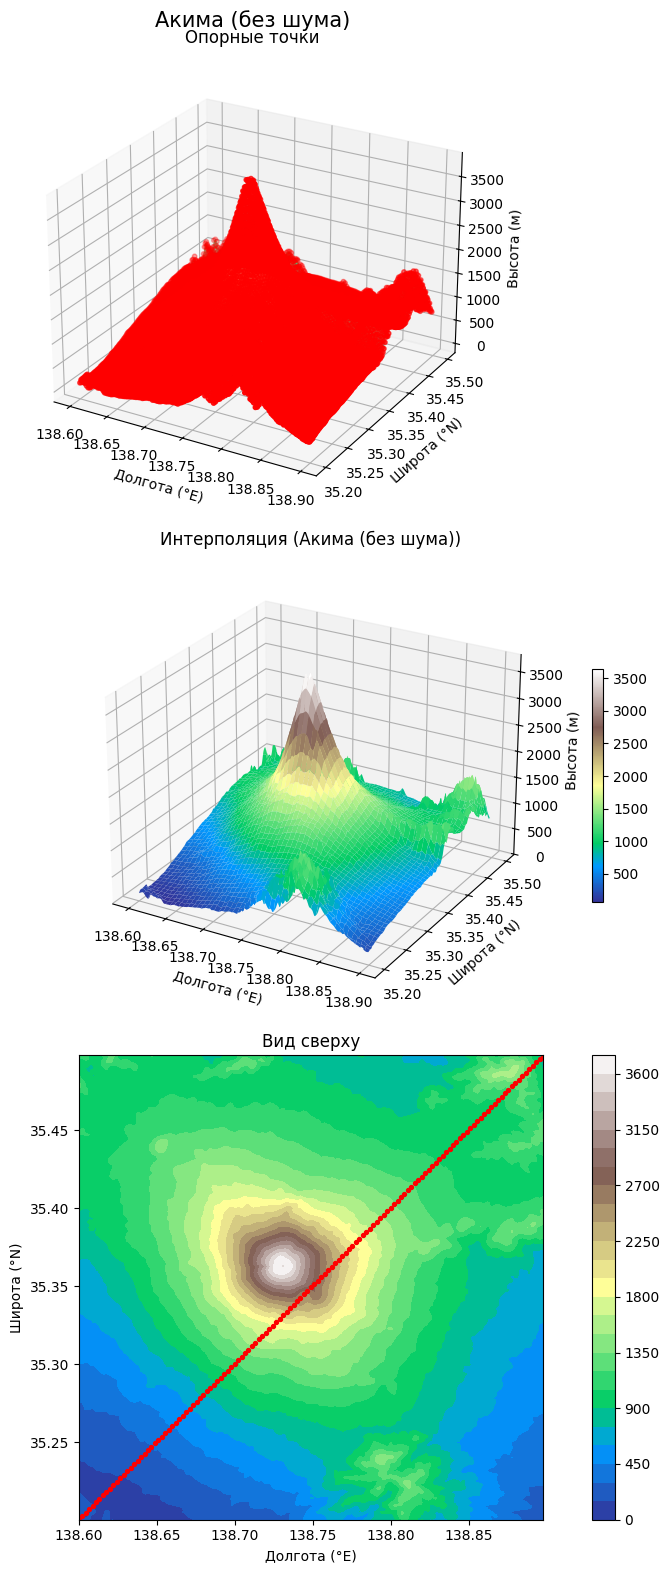

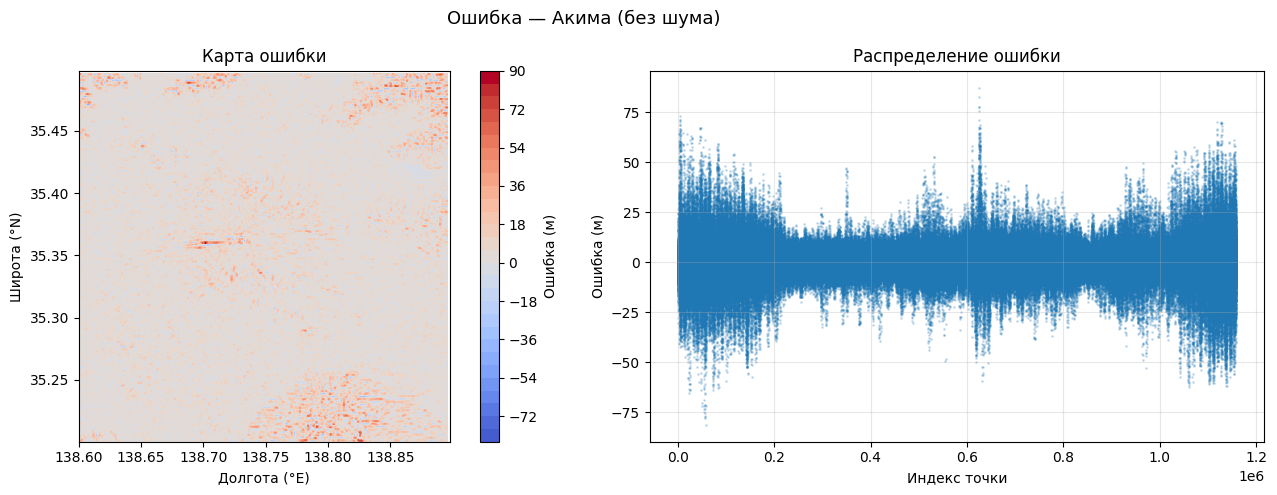

Интерполяция P-сплайном...
P-сплайн | MAE=6.11 м | RMSE=10.59 м | MAX=279.19 м
P-сплайн | Объём=92.6507 | Отклонение=0.9497


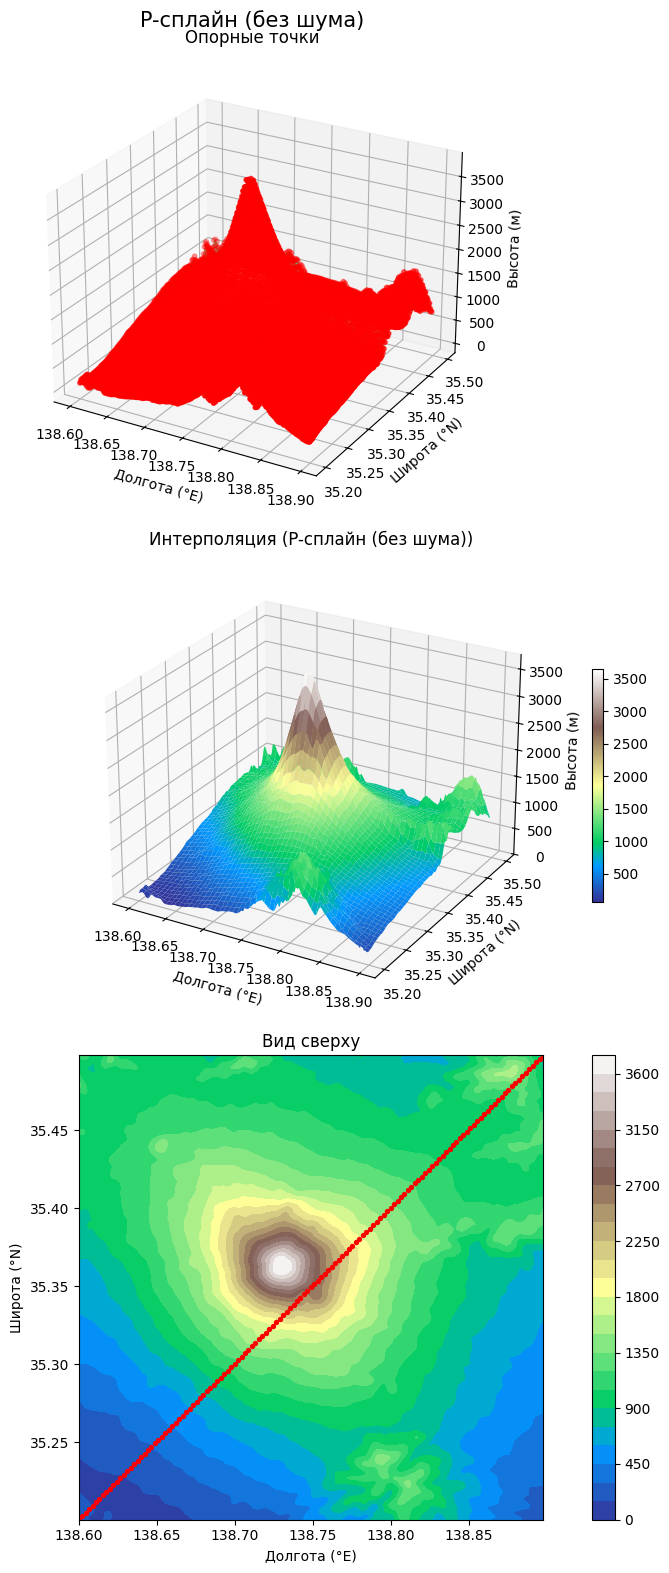

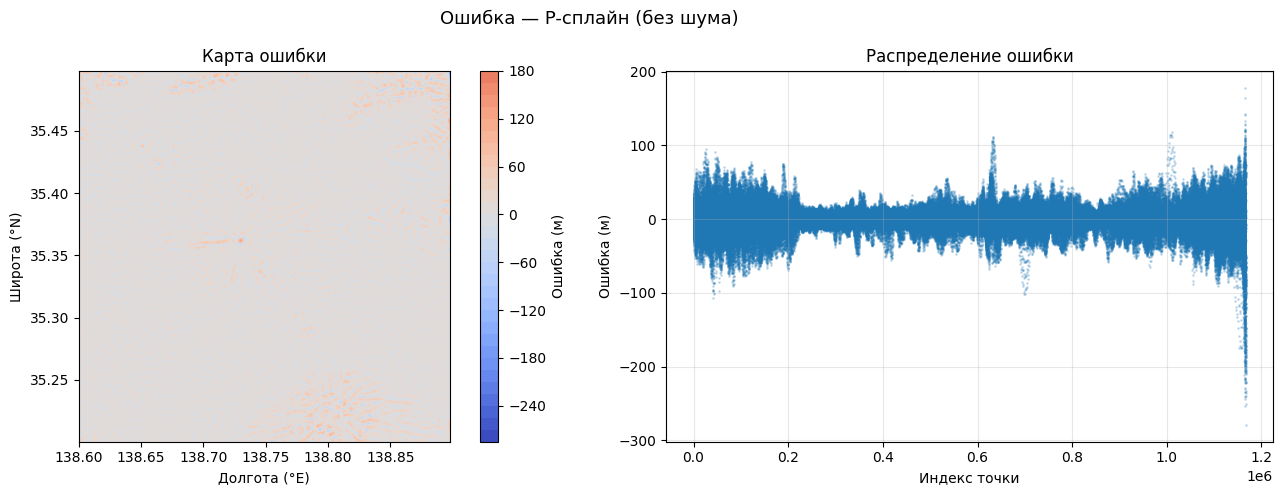

In [24]:
# ============================================================
# ЭКСПЕРИМЕНТ 1: без шума
# ============================================================

print("\n=== Эксперимент 1: без шума ===")

# -- Акима --
print("Интерполяция Акимой...")
Z_akima = akima_surface_2d(X_pts, Y_pts, Z_pts, X_smooth, Y_smooth)

Z_akima_on_raw = akima_surface_2d(X_smooth, Y_smooth, Z_akima, X_coords, Y_coords)
err_akima, mae_a, rmse_a, max_a = compute_metrics(Z_akima_on_raw, Z_raw)

vol_akima = compute_volume(Z_akima, X_smooth, Y_smooth)

print(f"Акима | MAE={mae_a:.2f} м | RMSE={rmse_a:.2f} м | MAX={max_a:.2f} м")
print(f"Акима | Объём={vol_akima:.4f} | Отклонение={abs(vol_akima-vol_true):.4f}")

plot_results(Xg_smooth, Yg_smooth, Z_akima, Z_pts, X_pts, Y_pts,
             err_akima, 'Акима (без шума)', x_label, y_label)

# -- P-сплайн --
print("Интерполяция P-сплайном...")

n_basis = 89
lam = 0.012254341711072526

A, kx, ky = pspline_2d_fit(X_pts, Y_pts, Z_pts, n_basis=n_basis, lam=lam,
                             x_range=(X_coords[0], X_coords[-1]),
                             y_range=(Y_coords[0], Y_coords[-1]))
Z_psp = pspline_2d_eval(A, kx, ky, X_smooth, Y_smooth)

Z_psp_on_raw = pspline_2d_eval(A, kx, ky, X_coords, Y_coords)
err_psp, mae_p, rmse_p, max_p = compute_metrics(Z_psp_on_raw, Z_raw)

vol_psp = compute_volume(Z_psp, X_smooth, Y_smooth)

print(f"P-сплайн | MAE={mae_p:.2f} м | RMSE={rmse_p:.2f} м | MAX={max_p:.2f} м")
print(f"P-сплайн | Объём={vol_psp:.4f} | Отклонение={abs(vol_psp-vol_true):.4f}")

plot_results(Xg_smooth, Yg_smooth, Z_psp, Z_pts, X_pts, Y_pts,
             err_psp, 'P-сплайн (без шума)', x_label, y_label)


=== Эксперимент 2: с шумом ===
Интерполяция Акимой (шум)...
Акима (шум) | MAE=19.44 м | RMSE=24.58 м | MAX=143.20 м
Акима (шум) | Объём=92.6671 | Отклонение=0.9333


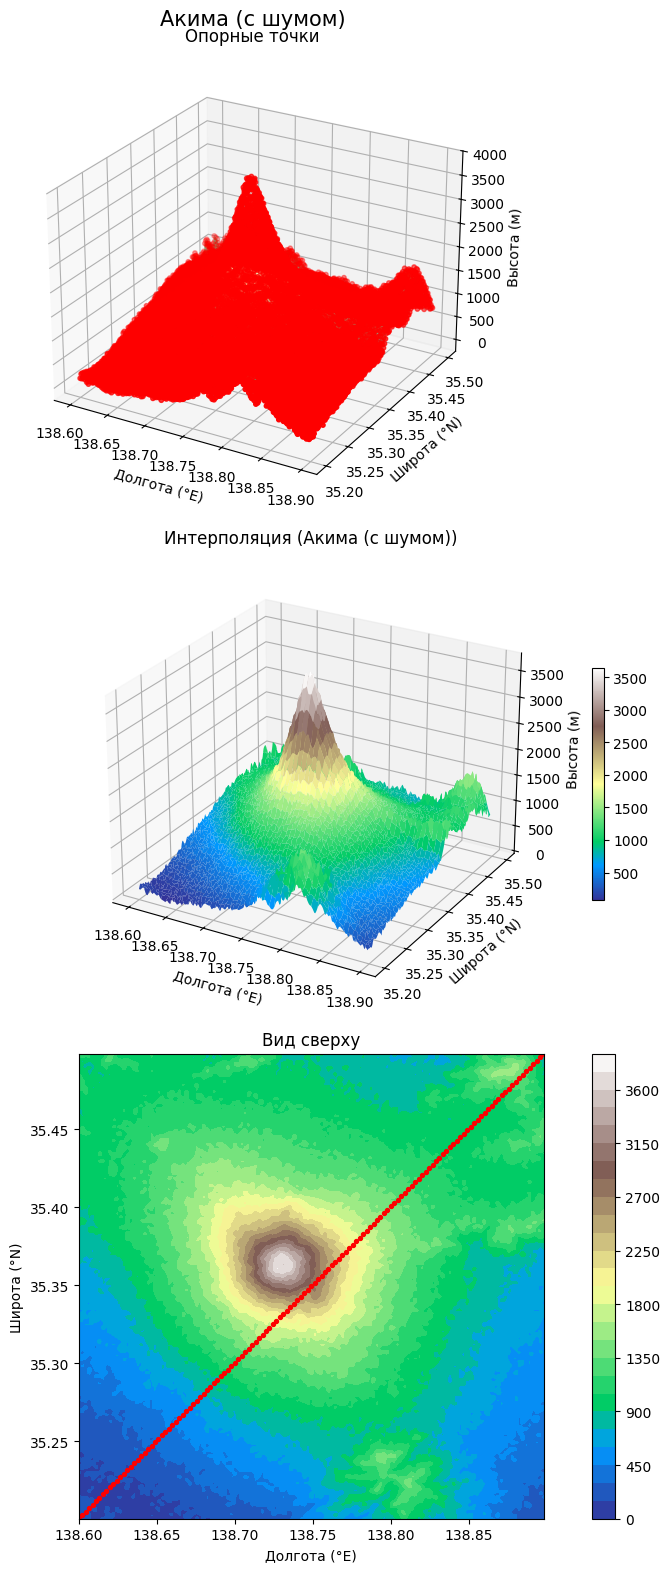

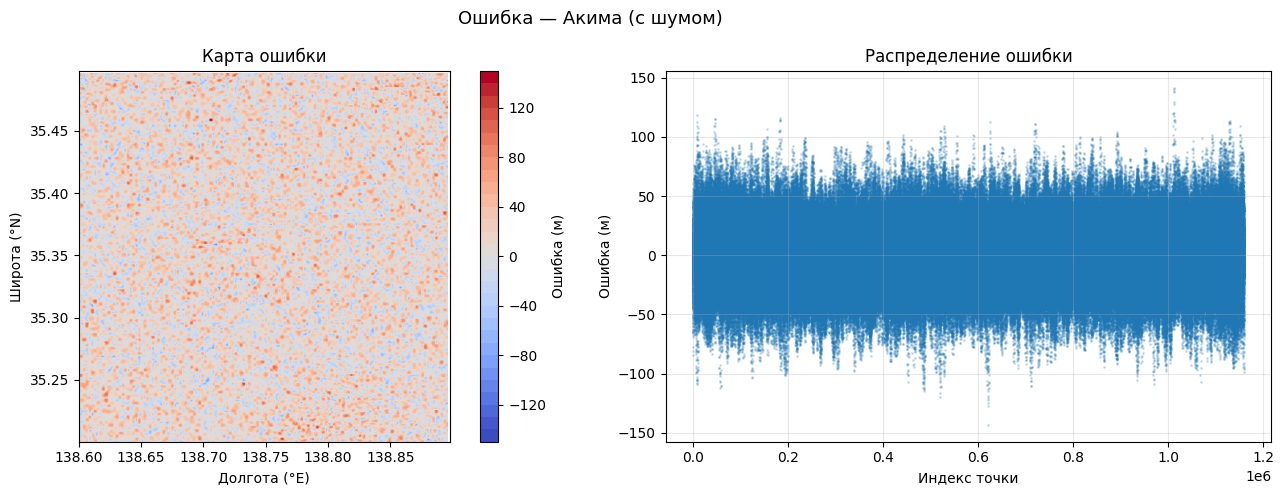

Интерполяция P-сплайном (шум)...
P-сплайн (шум) | MAE=12.04 м | RMSE=19.02 м | MAX=274.44 м
P-сплайн (шум) | Объём=92.6681 | Отклонение=0.9323


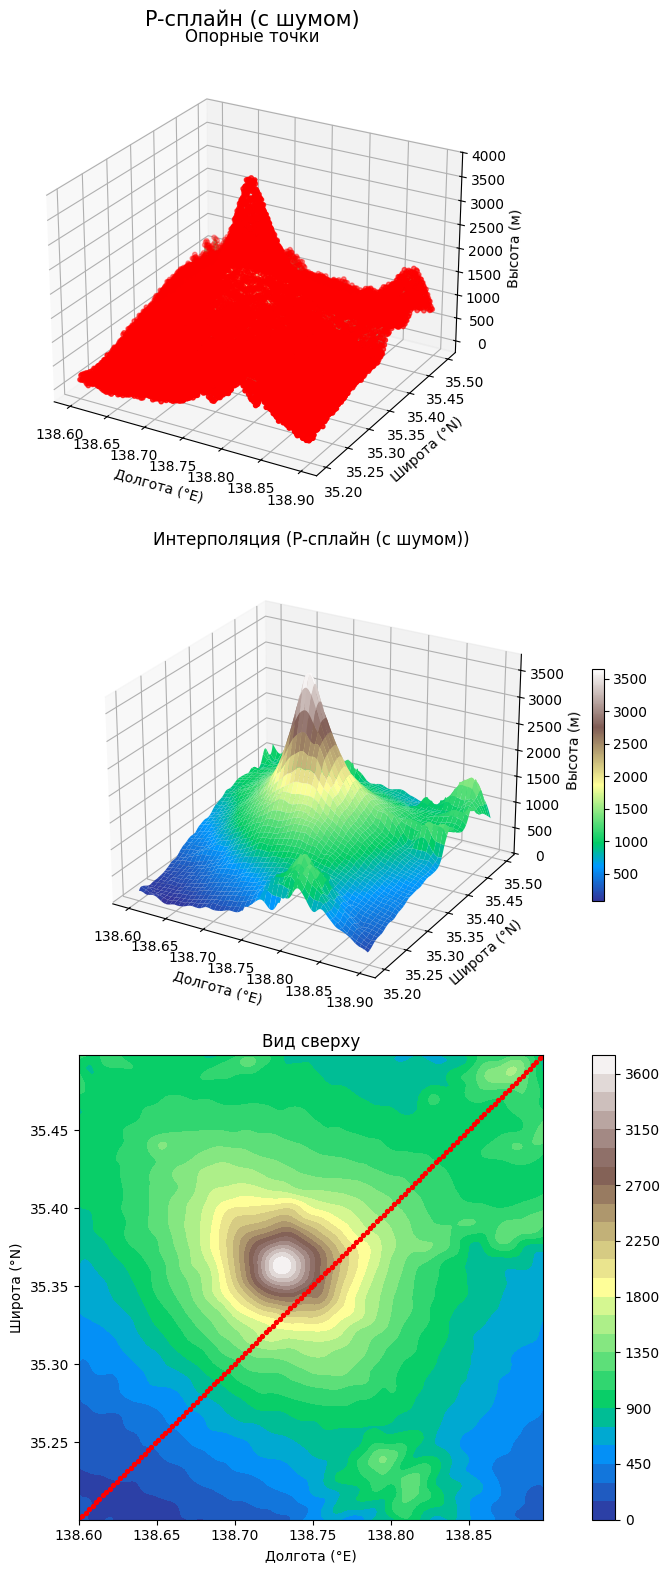

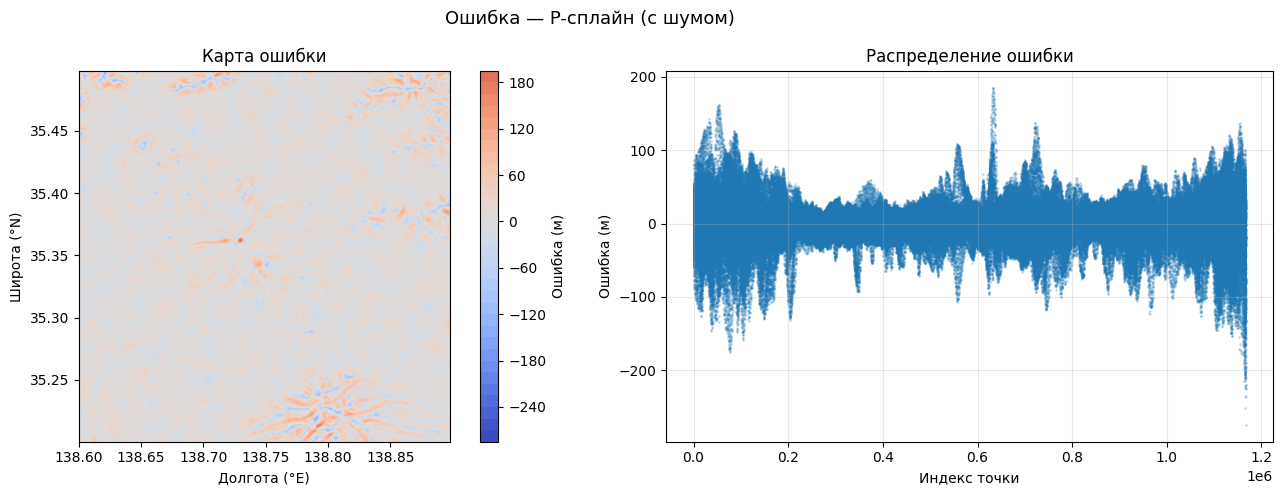

In [25]:
# ============================================================
# ЭКСПЕРИМЕНТ 2: с шумом
# ============================================================

print("\n=== Эксперимент 2: с шумом ===")

n_basis = 56
lam = 0.1320515764016064

noise_std = 30.0  # метры
np.random.seed(42)
Z_pts_noisy = Z_pts + np.random.normal(0, noise_std, Z_pts.shape)

# -- Акима с шумом --
print("Интерполяция Акимой (шум)...")
Z_akima_n = akima_surface_2d(X_pts, Y_pts, Z_pts_noisy, X_smooth, Y_smooth)

Z_akima_n_on_raw = akima_surface_2d(X_smooth, Y_smooth, Z_akima_n, X_coords, Y_coords)
err_akima_n, mae_an, rmse_an, max_an = compute_metrics(Z_akima_n_on_raw, Z_raw)

vol_akima_n = compute_volume(Z_akima_n, X_smooth, Y_smooth)

print(f"Акима (шум) | MAE={mae_an:.2f} м | RMSE={rmse_an:.2f} м | MAX={max_an:.2f} м")
print(f"Акима (шум) | Объём={vol_akima_n:.4f} | Отклонение={abs(vol_akima_n-vol_true):.4f}")

plot_results(Xg_smooth, Yg_smooth, Z_akima_n, Z_pts_noisy, X_pts, Y_pts,
             err_akima_n, 'Акима (с шумом)', x_label, y_label)

# -- P-сплайн с шумом --
print("Интерполяция P-сплайном (шум)...")
A_n, kx_n, ky_n = pspline_2d_fit(X_pts, Y_pts, Z_pts_noisy, n_basis=n_basis, lam=lam,
                                   x_range=(X_coords[0], X_coords[-1]),
                                   y_range=(Y_coords[0], Y_coords[-1]))
Z_psp_n = pspline_2d_eval(A_n, kx_n, ky_n, X_smooth, Y_smooth)

Z_psp_n_on_raw = pspline_2d_eval(A_n, kx_n, ky_n, X_coords, Y_coords)
err_psp_n, mae_pn, rmse_pn, max_pn = compute_metrics(Z_psp_n_on_raw, Z_raw)

vol_psp_n = compute_volume(Z_psp_n, X_smooth, Y_smooth)

print(f"P-сплайн (шум) | MAE={mae_pn:.2f} м | RMSE={rmse_pn:.2f} м | MAX={max_pn:.2f} м")
print(f"P-сплайн (шум) | Объём={vol_psp_n:.4f} | Отклонение={abs(vol_psp_n-vol_true):.4f}")

plot_results(Xg_smooth, Yg_smooth, Z_psp_n, Z_pts_noisy, X_pts, Y_pts,
             err_psp_n, 'P-сплайн (с шумом)', x_label, y_label)


Метод                          MAE     RMSE        MAX           ΔV
Акима (без шума)              4.30     7.01      87.17       0.9497
P-сплайн (без шума)           6.11    10.59     279.19       0.9497
Акима (шум)                  19.44    24.58     143.20       0.9333
P-сплайн (шум)               12.04    19.02     274.44       0.9323


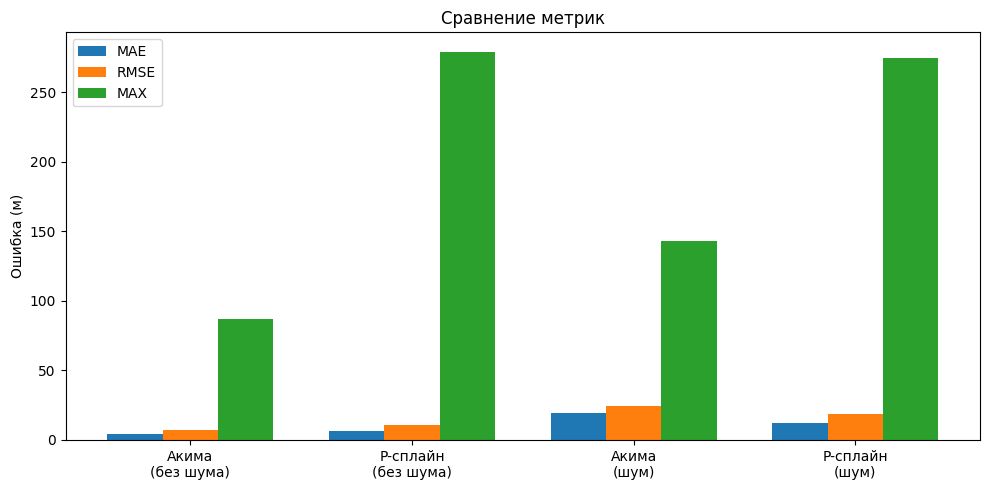

In [26]:
# ============================================================
# Итоговая таблица
# ============================================================

print("\n" + "="*65)
print(f"{'Метод':<25} {'MAE':>8} {'RMSE':>8} {'MAX':>10} {'ΔV':>12}")
print("="*65)
print(f"{'Акима (без шума)':<25} {mae_a:>8.2f} {rmse_a:>8.2f} {max_a:>10.2f} {abs(vol_akima-vol_true):>12.4f}")
print(f"{'P-сплайн (без шума)':<25} {mae_p:>8.2f} {rmse_p:>8.2f} {max_p:>10.2f} {abs(vol_psp-vol_true):>12.4f}")
print(f"{'Акима (шум)':<25} {mae_an:>8.2f} {rmse_an:>8.2f} {max_an:>10.2f} {abs(vol_akima_n-vol_true):>12.4f}")
print(f"{'P-сплайн (шум)':<25} {mae_pn:>8.2f} {rmse_pn:>8.2f} {max_pn:>10.2f} {abs(vol_psp_n-vol_true):>12.4f}")
print("="*65)

# сравнительный график метрик
labels = ['Акима\n(без шума)', 'P-сплайн\n(без шума)', 'Акима\n(шум)', 'P-сплайн\n(шум)']
maes   = [mae_a,  mae_p,  mae_an,  mae_pn]
rmses  = [rmse_a, rmse_p, rmse_an, rmse_pn]
maxes  = [max_a,  max_p,  max_an,  max_pn]

x = np.arange(len(labels))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, maes,  w, label='MAE')
ax.bar(x,     rmses, w, label='RMSE')
ax.bar(x + w, maxes, w, label='MAX')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Ошибка (м)')
ax.set_title('Сравнение метрик')
ax.legend()
plt.tight_layout()
plt.show()